In [11]:
#PREPROCESSING DATA

from datetime import datetime    
with open('C:/Users/sammi/Documents/Grad School/EAS 503 python/EAS final/MML_AEP_Marine Mammal Food Habits Reference Collection, 1995-2018.csv','r') as f:       
        f=f.readlines()
        #print(len(f))                          #1008 data points before cleaning data
        header=(f[0])
        header=header.split(',')
        len(header)
    
        species=[]                              #want to draw conclusions on how many different types of bones have been recorded
        need_to_edit=[]                         # notes which datasets have missing values
        check=[]                                #checkingmissing values organized by column header
        for i in range(1,len(f)):
            f[i]=f[i].split(',')
            if f[i][6] not in species:
                species.append(f[i][6])
            if len(f[i])!=19:
                need_to_edit.append(i)
            if (f[i][9])!='':
                check.append(i)
        for i in range(0,len(need_to_edit)-4):
            f[need_to_edit[i]][2]=f[need_to_edit[i]][2]+f[need_to_edit[i]][3]
            f[need_to_edit[i]].pop(3)
        need_to_edit=need_to_edit[-4:]
        f.pop(669) #removing unusable data
        f.pop(617)
        f.pop(607)
        f.pop(604)
        f.pop(1004)  
    
#check:
#0:1008 1:993 2:918 3:1006 4:1005 5:1005 6:1000 7:847 8:198 9:682 10:35 11:317 12:189 13:104 14:62 15:97 16:13 17:65 18:993
#removing all columns with <33% of the data filled because they do not have enough information for me to obtain useful results 
#of what type of prey are consumed. As stated in my writeup, these columns do list crutial information as I am looking mostly at species and size.
#columns 0-7,9 will be used
    

        year_cat=[]                                #looking at dates. I adjust to datetime later in code
        month_cat=[]
        day_cat=[]
        date_splt_list=[]
        for i in range(1,len(f)):
            f[i]=f[i][0:10]
            f[i].pop(8)
            f[i][1]=f[i][1][0:10]
            date_splt=f[i][1].split('-')
            date_splt_list.append(date_splt)
        for i in range(0,len(date_splt_list)):
            if len(date_splt_list[i][0])!=4:
                date_splt_list[i]=[0000]
            year=int(date_splt_list[i][0])
            year_cat.append(year)


        f.pop(0)                                    #separating header from rest of data
        header=header[0:10]
        header.pop(8)

        verified=[]                                  #looping through the data to find the columns with multiple verifiers
        bone=[]
        family1=[]
        genus1=[]
        species1=[]
        cona1=[]
        species2=[]
        genus2=[]
        fam1=[]
        for i in range(0,len(f)):
            if f[i][2]=='"L.Lehman K.Hughes"':
                f[i][2]='L.Lehman K.Hughes'
                x=f[i][2].split(' ')
                y=[f[i][0],f[i][0]]
                for g in range(0,1):
                    verified=verified+x
            else:
                verified.append(f[i][2])
                y=[f[i][0]]
            bone=bone+y
    #f[i].pop(2)
            fam=f[i][3]
            if (fam,) not in family1:                   #looping through data to make dictionaries for other tables in order to comply with 3NF
                family1.append((fam,))
            if fam not in fam1:
                fam1.append(fam)
                
    #f[i].pop(3)
            gen=f[i][4]
            if gen not in genus1:
                genus1.append(gen)
            spe=f[i][5]
            if spe not in species1:
                species1.append(spe)
                genus2.append(gen)
            cn=f[i][6]
            if cn not in cona1:
                cona1.append(cn)
                species2.append(spe)
        gen=[]
        fam=[]
        spe=[]
        gen2=[]
        cona=[]
        spe2=[]
        for i in range(0,len(f)):
            if f[i][4] not in gen:
                gen.append(f[i][4])
                fam.append(f[i][3])
            if f[i][5] not in spe:
                gen.append(f[i][5])
                gen2.append(f[i][4])
            if f[i][6] not in cona:
                cona.append(f[i][6])
                spe2.append(f[i][5])
        del f[i][4]
        del f[i][2]
        fa=range(1,len(family1))
        s=range(1,len(species2))

        family_fk_lookup = dict(zip(fam1,fa))
        species_lookup = dict(zip(species2,s))
        genus_lookup= dict(zip(genus2,s))
        values_ver=zip(bone,verified)
        genfam_list = [family_fk_lookup.get(item,item) for item in fam]
        genus_vals=list(zip(genus1,genfam_list))
    
        spefam_list = [genus_lookup.get(item,item) for item in gen2]
        species_vals=list(zip(species1,spefam_list))
        
        cona_list = [species_lookup.get(item,item) for item in spe2]
        cona_vals=list(zip(cona1,cona_list))
        data=f
        for i in range(0,len(data)):                 #removing data from other tables from data needed for records table
            data[i].pop(5)
            data[i].pop(4)
            data[i].pop(3)
            data[i].pop(2)
        yearlist=[]                                 #making columns for year, month, and day
        monthlist=[]
        daylist=[]
        for row in data:
            date_cat = row[1] 
            if date_cat:  
                date_obj = datetime.strptime(date_cat, '%Y-%m-%d')     
                year = date_obj.year
                month = date_obj.month
                day = date_obj.day
                        
            else:
                year, month, day = 0000, 00, 00       # Set to None if date is empty
            yearlist=yearlist+[year]
            monthlist=monthlist+[month]
            daylist= daylist+[day]
        
        for i in range(0,len(data)):
            data[i].append(yearlist[i])
            data[i].append(monthlist[i])
            data[i].append(daylist[i])
        data.pop(1002)


In [12]:
#CLEARING/FRESH DATABASE

import sqlite3
conn = sqlite3.connect('finals2.db')
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

for table in tables:
    table_name = table[0]
    cursor.execute(f"DELETE FROM {table_name};")
    conn.commit()
conn.close()

In [14]:
#CREATING NORMALIZED TABLES

import sqlite3
import pandas as pd
# creating genus table
conn = sqlite3.connect('finals2.db')
def create_genus(conn):
    clr_sql='''DROP TABLE IF EXISTS genusName;'''
    sql_gen_table='''
        CREATE TABLE genusName (
        genusID INTEGER PRIMARY KEY AUTOINCREMENT,
        genus TEXT NOT NULL,
        familyID INTEGER,
        FOREIGN KEY (familyID) REFERENCES family(familyID)
        )'''
    insert_sql ='''
        INSERT INTO genusName (genus, familyID)
        VALUES (?,?)
        '''
    with conn:
        cursor = conn.cursor()
        cursor.execute(clr_sql)
        cursor.execute(sql_gen_table)
        cursor.executemany(insert_sql, genus_vals)
        #conn.commit()
    return pd.read_sql_query("""SELECT * FROM genusName""", conn)
genus=create_genus(conn)
genus


#creating family table
conn = sqlite3.connect('finals2.db')
def create_family(conn):
    cursor = conn.cursor()
    clr_sql='''DROP TABLE IF EXISTS family;'''
    sql_fam='''
        CREATE TABLE family (
        familyID INTEGER PRIMARY KEY AUTOINCREMENT,
        familyName TEXT NOT NULL
        )'''
    insert_fam='''
        INSERT INTO Family (familyName)
        VALUES (?)
        '''
    with conn:
        conn.execute(clr_sql)
        cursor.execute(sql_fam)

        cursor.executemany(insert_fam, family1) 
        conn.commit() 

        cursor.execute('SELECT * FROM family')
    return pd.read_sql_query("""SELECT * FROM Family""", conn)
family=create_family(conn)


#creating species table
conn = sqlite3.connect('finals2.db')
def create_species(conn):
    clr_sql='''DROP TABLE IF EXISTS species;'''
    sql_spe_table='''
    CREATE TABLE IF NOT EXISTS species (
    speciesID INTEGER PRIMARY KEY AUTOINCREMENT,
    species TEXT NOT NULL,
    genusID INTEGER,
    FOREIGN KEY (genusID) REFERENCES genus(genusID)
    )'''
    insert_spe='''
    INSERT INTO species (species, genusID)
    VALUES (?,?)
    '''
    with conn:
        cursor = conn.cursor()
        cursor.execute(clr_sql)
        cursor.execute(sql_spe_table)
        cursor.executemany(insert_spe, species_vals)
        conn.commit()
    return pd.read_sql_query("""SELECT * FROM species""", conn)
species=create_species(conn)


#creating common name table
conn = sqlite3.connect('finals2.db')
def create_commonname(conn):
    conn = sqlite3.connect('finals2.db')
    clr_sql='''DROP TABLE IF EXISTS commonName;'''
    create_ver_sql='''
        CREATE TABLE IF NOT EXISTS commonName (
        cnID INTEGER PRIMARY KEY AUTOINCREMENT,
        common_name TEXT NOT NULL,
        speciesID INTEGER,
        FOREIGN KEY (speciesID) REFERENCES species(speciesID)
        )'''
    insert_sql_verifications = '''
        INSERT INTO commonName (common_name, speciesID)
        VALUES (?, ?)
        '''
    with conn:
        cursor = conn.cursor()
        cursor.execute(clr_sql)
        cursor.execute(create_ver_sql)
        cursor.executemany(insert_sql_verifications, cona_vals)
    return pd.read_sql_query("""SELECT * FROM commonName""", conn)

commonName=create_commonname(conn)
commonName


#creating verified_by table
conn = sqlite3.connect('finals2.db')
def create_verified(conn):
    conn = sqlite3.connect('finals2.db')
    clr_sql='''DROP TABLE IF EXISTS verified;'''
    create_ver_sql='''
        CREATE TABLE verified (
        verificationID INTEGER PRIMARY KEY AUTOINCREMENT,  
        bone INTEGER,
        verified_by TEXT
        )'''
    insert_sql_verifications = '''
        INSERT INTO verified (bone, verified_by)
        VALUES (?, ?)
        '''
    with conn:
        cursor = conn.cursor()
        cursor.execute(clr_sql)
        cursor.execute(create_ver_sql)
        cursor.executemany(insert_sql_verifications, values_ver)
    return pd.read_sql_query("""SELECT * FROM verified""", conn)
verified=create_verified(conn)

#creating records table
conn = sqlite3.connect('finals2.db')
def create_records(conn):
    clr_sql='''DROP TABLE IF EXISTS records;'''
    sql_table='''
        CREATE TABLE IF NOT EXISTS records(
        boneID INTEGER PRIMARY KEY AUTOINCREMENT,
        bone TEXT,
        date_cat TEXT,
        common_name TEXT,
        sl_cm REAL,
        wt_gm REAL,
        year INTEGER,
        month INTEGER,
        day INTEGER
        )
        '''
    insert_sql = '''
    INSERT INTO records (bone, date_cat, common_name, sl_cm, wt_gm, year, month,day)
    VALUES (?, ?, ?, ?, ?, ?, ?,?)
    '''
    with conn:
        cursor = conn.cursor()
        cursor.execute(clr_sql)
        cursor.execute(sql_table)
        cursor.executemany(insert_sql, data)
    length=[]
    for i in range(0,len(data)):
        if len(data[i])!=8:
            length.append(data[i])
        

    return pd.read_sql_query("""SELECT * FROM records""", conn)
records=create_records(conn)




In [15]:
#REMOVING OUTLIERS FROM AVERAGE MEASUREMENTS 

import numpy as np
df=records
df.replace("", np.nan, inplace=True)
df['sl_cm'] = pd.to_numeric(df['sl_cm'], errors='coerce')
df=df.dropna()
sorted_by_year = df.sort_values(by='year', ascending=True)
#whats up with 2004
len_2004 = df[df['year'] == 2004]['sl_cm']
#print(len_2004)

Q1 = sorted_by_year['sl_cm'].quantile(0.25)
Q3 = sorted_by_year['sl_cm'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
filtered_df = sorted_by_year[(sorted_by_year['sl_cm'] >= lower_bound) & (sorted_by_year['sl_cm'] <= upper_bound)]


mean_len_by_yr=filtered_df.groupby('year')['sl_cm'].mean()
OGmean_len_by_yr=df.groupby('year')['sl_cm'].mean()
print(OGmean_len_by_yr, mean_len_by_yr)


df=records
df.replace("", np.nan, inplace=True)
df['wt_gm'] = pd.to_numeric(df['wt_gm'], errors='coerce')
df=df.dropna()
sorted_by_year = df.sort_values(by='year', ascending=True)
#whats up with 2004
len_2004 = df[df['year'] == 2004]['wt_gm']
#print(len_2004)

Q1 = sorted_by_year['wt_gm'].quantile(0.25)
Q3 = sorted_by_year['wt_gm'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
filtered_df = sorted_by_year[(sorted_by_year['wt_gm'] >= lower_bound) & (sorted_by_year['wt_gm'] <= upper_bound)]


mean_wt_by_yr=filtered_df.groupby('year')['wt_gm'].mean()
OGmean_wt_by_yr=df.groupby('year')['wt_gm'].mean()
print(OGmean_wt_by_yr, mean_wt_by_yr)

year
1995     22.148544
1996     16.279688
1997     14.687500
1998     22.369565
2000     17.028235
2004    146.050000
2009     17.130000
2010     19.803191
2011     24.543750
2012     22.387097
2014     26.724675
2015     19.260000
2018     21.500000
Name: sl_cm, dtype: float64 year
1995    21.448515
1996    16.279688
1997    14.687500
1998    20.723256
2000    15.474074
2004    24.933333
2009    17.130000
2010    19.228261
2011    18.757143
2012    21.173333
2014    24.428571
2015    15.733333
2018    18.238095
Name: sl_cm, dtype: float64
year
1995    258.433107
1996     54.081250
1997     65.952500
1998    211.967391
2000    119.569412
2004    560.000000
2009     70.930000
2010    115.553409
2011    111.546429
2012    161.885135
2014    207.850794
2015     76.640000
2018    123.700000
Name: wt_gm, dtype: float64 year
1995    164.365326
1996     54.081250
1997     49.182051
1998    104.302632
2000     76.380000
2004    270.000000
2009     70.930000
2010    115.553409
2011    111.5464

In [16]:
#function to find records belonging to a specific species 
def species_info_ex(conn, species_name):
    query = '''
    SELECT 
    s.species,
    r.boneID, 
    r.bone, 
    r.date_cat, 
    r.sl_cm, 
    r.wt_gm, 
    r.year, 
    r.month, 
    r.day
    FROM 
        records r
    JOIN commonName cn ON r.common_name = cn.common_name  -- Join records with commonName on common_name
    JOIN species s ON cn.speciesID = s.speciesID  -- Join commonName with species on speciesID
    WHERE s.species = ?
    ;
    '''
    return pd.read_sql_query(query, conn, params=(species_name,))

#example species selsction
sie=species_info_ex(conn,'fimbria')
sie

,species,boneID,bone,date_cat,sl_cm,wt_gm,year,month,day
0,fimbria,75,NMML 0006bn,1995-09-09,,128.9,1995,9,9
1,fimbria,204,NMML 0056bn,1995-09-09,23.1,169.6,1995,9,9
2,fimbria,259,NMML 0114bn,2009-05-01,14.6,38.1,2009,5,1
3,fimbria,260,NMML 0115bn,2009-05-01,15.3,47.6,2009,5,1
4,fimbria,4,NMML 0146bn,1995-12-04,33.0,497.0,1995,12,4
5,fimbria,284,NMML 0147bn,1995-12-04,38.0,960.0,1995,12,4
6,fimbria,285,NMML 0148bn,1995-12-04,37.5,500.0,1995,12,4
7,fimbria,292,NMML 0155bn,1995-01-24,32.0,374.0,1995,1,24
8,fimbria,300,NMML 0163bn,1995-01-24,29.2,355.0,1995,1,24
9,fimbria,301,NMML 0164bn,1995-01-24,31.5,410.0,1995,1,24


In [17]:
#AVERAGE MEASUREMENTS BY SPECIES

def avg_by_species(conn):
    query = '''
    SELECT 
    s.species,
    g.genus,
    f.familyName,
    r.common_name,  -- Keep common_name as it is from records table
    AVG(NULLIF(ROUND(r.sl_cm,2),0.00)) AS avg_length_cm, 
    AVG(NULLIF(ROUND(r.wt_gm,2),0.00)) AS avg_weight_gm 
    FROM 
        records r
    JOIN commonName cn ON r.common_name = cn.common_name  -- Join records with commonName on common_name
    JOIN species s ON cn.speciesID = s.speciesID  -- Join commonName with species on speciesID
    JOIN genusName g ON s.genusID = g.genusID  -- Join species with genusName on familyID
    JOIN family f ON g.familyID = f.familyID  -- Join genusName with family on familyID
    GROUP BY s.species;
    '''
    return pd.read_sql_query(query, conn)
avg_species_bone_measurement=avg_by_species(conn)
print (avg_species_bone_measurement)

            species            genus         familyName  \
0                      Nannobrachium        Myctophidae   
1              abei     Tetragonurus     Tetragonuridae   
2         acanthias        Ammodytes        Ammodytidae   
3    accipenserinus         Enophrys           Cottidae   
4           affinis  Synaphobranchus  Synaphobranchidae   
..              ...              ...                ...   
183     williamsoni      Bathymaster    Bathymasteridae   
184         xantusi    Bryozoichthys        Stichaeidae   
185       zacentrus         Eleginus            Gadidae   
186           zapus    Citharichthys    Paralichthyidae   
187       zugmayeri        Melanonus        Melanonidae   

               common_name  avg_length_cm  avg_weight_gm  
0           Kelp greenling      20.085000     170.368182  
1                 Albacore            NaN            NaN  
2                Barreleye      11.750000            NaN  
3        Redtail surfperch      30.400000     948.00000

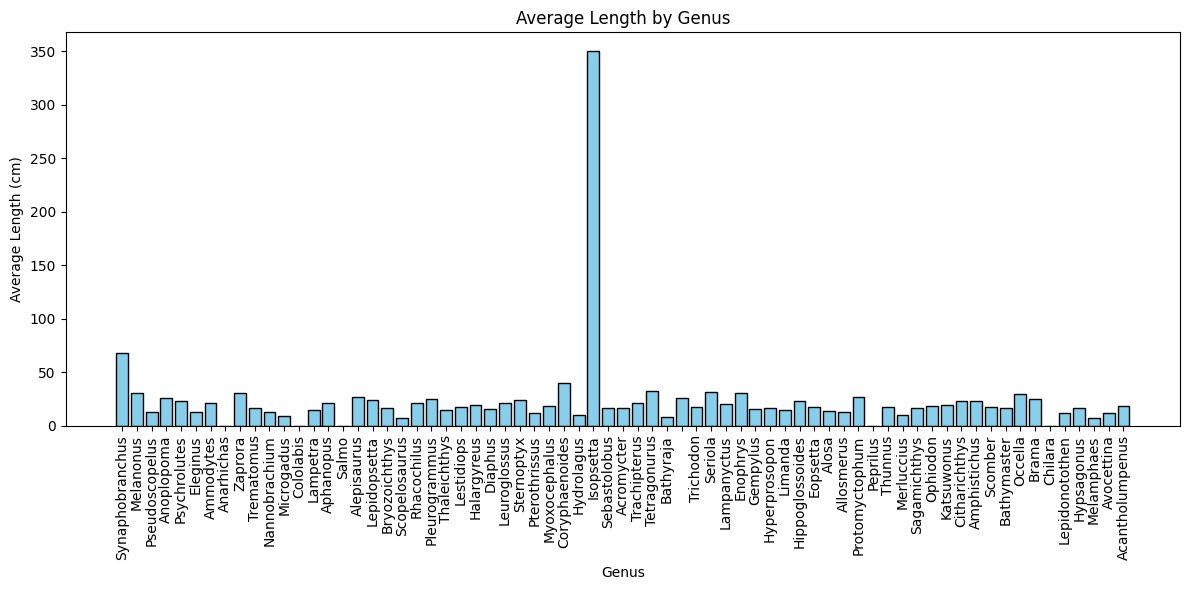

In [18]:
#BONE LENGTH BY GENUS VISUAL

import matplotlib.pyplot as plt
conn = sqlite3.connect('finals2.db')
def sl_hist(conn):
    query = '''
    SELECT g.genus, AVG(sl_cm) AS avg_length_cm
    FROM records r
    JOIN commonName cn ON r.common_name = cn.common_name  -- Join records with commonName on common_name
    JOIN species s ON cn.speciesID = s.speciesID  -- Join commonName with species on speciesID
    JOIN genusName g ON s.genusID = g.genusID  -- Join species with genusName on familyID
    WHERE sl_cm IS NOT NULL
    GROUP BY g.genusID;
    '''
    df = pd.read_sql_query(query, conn)

    
    plt.figure(figsize=(12,6))
    plt.bar(df['genus'], df['avg_length_cm'],
            color='skyblue',
            edgecolor='black')

    plt.title('Average Length by Genus')
    plt.xlabel('Genus')
    plt.ylabel('Average Length (cm)')
    plt.xticks(rotation=90)
    plt.tight_layout()

    plt.show()
sl_hist(conn)

In [78]:
#From the histogram above we can see that isopsetta likely contains an outltlier. 
#This genus contains only one species that is an average size of 35-40 cm.
#It is possible that the measurements were recorded in the wrong units or have a misplaced decimal. 
#This outlying datapoint can be excluded from future analysis as seen below

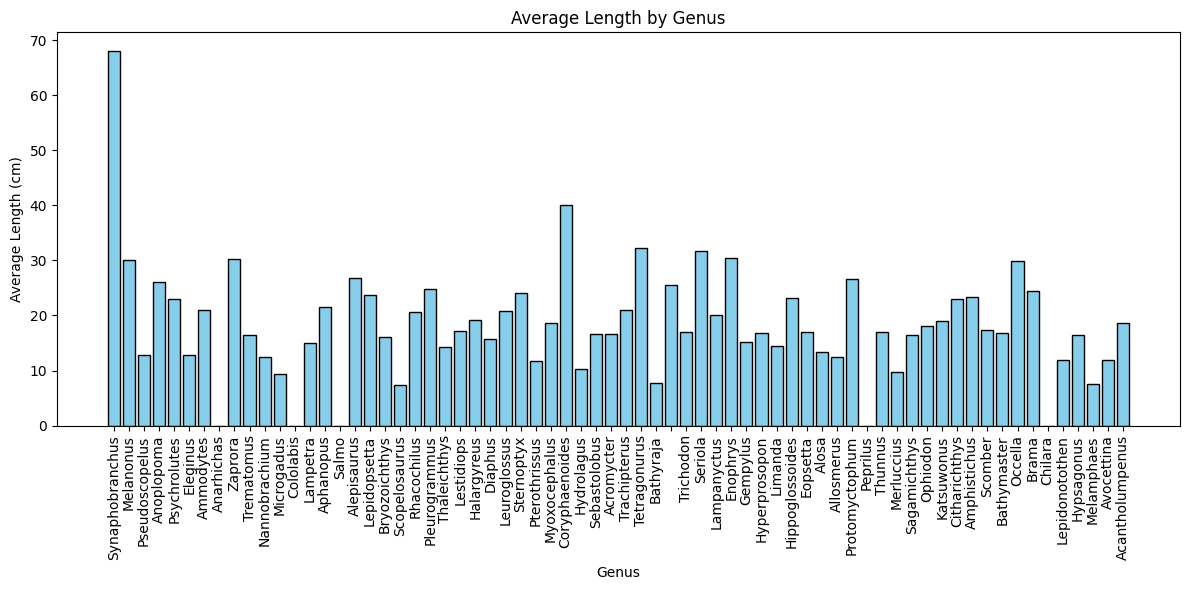

In [20]:
def sl_hist(conn):
    query = '''
    SELECT g.genus, AVG(sl_cm) AS avg_length_cm
    FROM records r
    JOIN commonName cn ON r.common_name = cn.common_name  -- Join records with commonName on common_name
    JOIN species s ON cn.speciesID = s.speciesID  -- Join commonName with species on speciesID
    JOIN genusName g ON s.genusID = g.genusID  -- Join species with genusName on familyID
    WHERE sl_cm IS NOT NULL
    AND genus IS NOT 'Isopsetta'
    GROUP BY g.genusID;
    '''
    df = pd.read_sql_query(query, conn)

    
    plt.figure(figsize=(12,6))
    plt.bar(df['genus'], df['avg_length_cm'],
            color='skyblue',
            edgecolor='black')

    plt.title('Average Length by Genus')
    plt.xlabel('Genus')
    plt.ylabel('Average Length (cm)')
    plt.xticks(rotation=90)
    plt.tight_layout()

    plt.show()
sl_hist(conn)

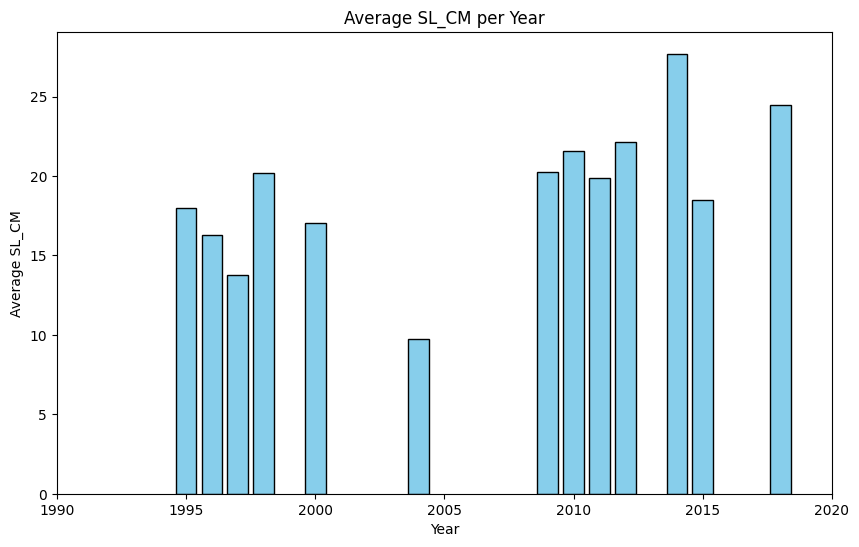

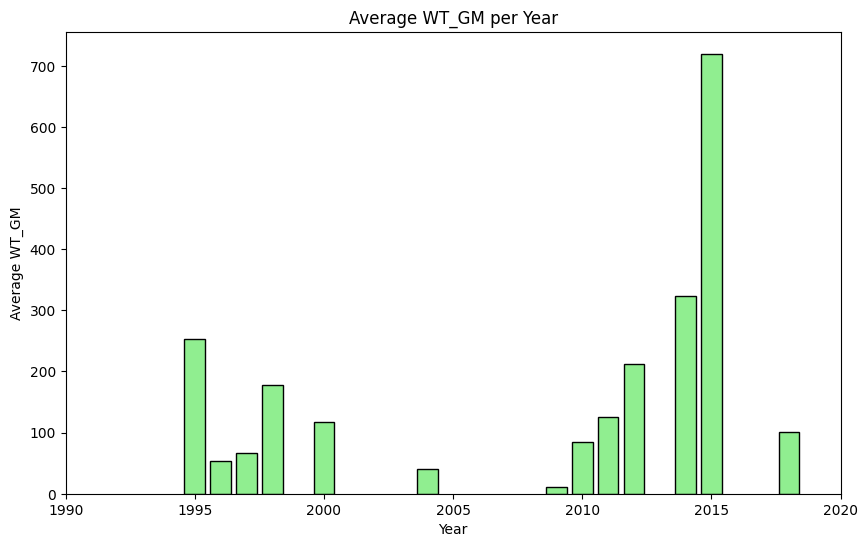

None None


In [21]:
import matplotlib.pyplot as plt
conn = sqlite3.connect('finals2.db')
def sl_hist(conn):
    query = '''
    SELECT year, AVG(sl_cm) AS avg_sl_cm
    FROM records
    WHERE year IS NOT NULL
    GROUP BY year
    ORDER BY year;
    '''
    df = pd.read_sql_query(query, conn)

    plt.figure(figsize=(10, 6))
    plt.bar(df['year'], df['avg_sl_cm'], color='skyblue', edgecolor='black')
    plt.xlim(1990, 2020)   #x-axis range
    plt.xticks(range(1990, 2021, 5))

    plt.title('Average SL_CM per Year')
    plt.xlabel('Year')
    plt.ylabel('Average SL_CM')

    return plt.show()


conn = sqlite3.connect('finals2.db')
def wt_hist(conn):
    query = '''
    SELECT year, AVG(wt_gm) AS avg_wt_gm
    FROM records
    WHERE year IS NOT NULL
    GROUP BY year
    ORDER BY year;
    '''
    df = pd.read_sql_query(query, conn)

    plt.figure(figsize=(10, 6))
    plt.bar(df['year'], df['avg_wt_gm'], color='lightgreen', edgecolor='black')
    plt.xlim(1990, 2020)   #x-axis range
    plt.xticks(range(1990, 2021, 5))

    plt.title('Average WT_GM per Year')
    plt.xlabel('Year')
    plt.ylabel('Average WT_GM')

    return plt.show()
print(sl_hist(conn),wt_hist(conn))


In [ ]:
#These bar graphs show similar trends in length and weight of fragments with 2015 having a noticable increase in aveages for weight and length.
#This stability may reflect sustained ecosystem productivity and the continued availability of suitable prey resources for cetaceans and pinnipeds.